In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
# ============================================================
# Rebuild as fixed-location time series (needed for forecasting features)
# ============================================================

# Reload full dataset (not the random 2M sample)
df_full = pd.read_csv(r"E:/sih/era5_india_merged.csv")
df_full["valid_time"] = pd.to_datetime(df_full["valid_time"])

# Check how many unique grid points exist
unique_locs = df_full[["latitude", "longitude"]].drop_duplicates()
print(f"Unique grid points: {len(unique_locs)}")

# Sample a fixed set of locations, but keep ALL their timestamps
n_locations = 200  # adjust based on unique_locs count / memory
sampled_locs = unique_locs.sample(n=n_locations, random_state=42)

df = df_full.merge(sampled_locs, on=["latitude", "longitude"], how="inner")

# Sort by location then time — critical for correct lag/rolling calculations
df = df.sort_values(["latitude", "longitude", "valid_time"]).reset_index(drop=True)

print(f"Time-series dataset shape: {df.shape}")
print(f"Date range: {df['valid_time'].min()} to {df['valid_time'].max()}")

Unique grid points: 15609
Time-series dataset shape: (392600, 12)
Date range: 2023-05-01 06:00:00 to 2026-08-30 08:00:00


In [3]:
# ==========================
# 3. Dataset Overview
# ==========================

print("Shape :", df.shape)

print("\nInformation")
df.info()

print("\nStatistical Summary")
display(df.describe(include="all"))

Shape : (392600, 12)

Information
<class 'pandas.DataFrame'>
RangeIndex: 392600 entries, 0 to 392599
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   valid_time  392600 non-null  datetime64[us]
 1   latitude    392600 non-null  float64       
 2   longitude   392600 non-null  float64       
 3   tp          392600 non-null  float64       
 4   ssrd        392600 non-null  float64       
 5   number      392600 non-null  int64         
 6   expver      392600 non-null  int64         
 7   u10         392600 non-null  float64       
 8   v10         392600 non-null  float64       
 9   d2m         392600 non-null  float64       
 10  t2m         392600 non-null  float64       
 11  sp          392600 non-null  float64       
dtypes: datetime64[us](1), float64(9), int64(2)
memory usage: 35.9 MB

Statistical Summary


,valid_time,latitude,longitude,tp,ssrd,number,expver,u10,v10,d2m,t2m,sp
count,392600,392600.000000,392600.000000,3.926000e+05,3.926000e+05,392600.0,392600.000000,392600.000000,392600.000000,392600.000000,392600.000000,392600.000000
mean,2024-12-29 00:17:52.847682,21.646250,82.832500,3.175648e-04,2.451091e+06,0.0,1.493123,2.747341,1.544370,291.560833,299.387225,89709.550398
min,2023-05-01 06:00:00,6.000000,68.000000,0.000000e+00,2.944000e+03,0.0,1.000000,-16.334457,-17.081589,240.489010,258.529080,50953.406000
25%,2023-08-31 08:00:00,13.187500,75.125000,9.536743e-07,1.918784e+06,0.0,1.000000,0.246632,-0.334492,288.552917,299.094000,86386.037500
50%,2024-08-31 07:00:00,22.250000,82.375000,4.291534e-05,2.622912e+06,0.0,1.000000,2.408073,1.248001,297.335060,301.670170,98298.952500
75%,2025-08-31 06:00:00,29.750000,91.000000,2.298355e-04,3.101312e+06,0.0,1.000000,5.131893,3.250969,298.427000,304.278320,100654.035000
max,2026-08-30 08:00:00,38.000000,98.000000,3.746510e-02,4.349184e+06,0.0,5.000000,17.685425,29.735810,303.140620,322.054930,101509.670000
std,NaN,9.239779,8.823351,8.336570e-04,8.406957e+05,0.0,1.315038,3.426621,2.898720,10.955708,9.390706,16665.287015


In [4]:
# ==========================
# 5. Data Quality Assessment
# ==========================

print("Missing Values")
display(df.isnull().sum())

print()

print("Duplicate Rows")
print(df.duplicated().sum())

print()



Missing Values


valid_time    0
latitude      0
longitude     0
tp            0
ssrd          0
number        0
expver        0
u10           0
v10           0
d2m           0
t2m           0
sp            0
dtype: int64


Duplicate Rows
0



In [8]:
# ============================================================
# Data Cleaning: Missing Values, Duplicates, Range Checks
# ============================================================

print("Missing values before cleaning:")
print(df.isnull().sum())

# Drop rows with missing critical fields (can't compute WBGT without these)
critical_cols = ["t2m", "d2m", "u10", "v10", "ssrd", "latitude", "longitude", "valid_time"]
df = df.dropna(subset=critical_cols)

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

# Handle ERA5T vs ERA5 version mixing if present
if "expver" in df.columns:
    print(df["expver"].value_counts())
    # Keep only final ERA5 (usually expver==1); adjust based on what you see above
    df = df[df["expver"] == 1]

# Sanity range checks after engineering RH/WBGT (run this after your feature cell)

# Flag physically implausible WBGT (adjust bounds based on India's climate)
implausible = df[(df["WBGT"] < -10) | (df["WBGT"] > 50)]
print(f"Implausible WBGT rows: {len(implausible)}")
df = df[(df["WBGT"] >= -10) & (df["WBGT"] <= 50)]

print(f"\nFinal shape after cleaning: {df.shape}")

Missing values before cleaning:
valid_time       0
latitude         0
longitude        0
tp               0
ssrd             0
number           0
expver           0
u10              0
v10              0
d2m              0
t2m              0
sp               0
t2m_C            0
d2m_C            0
WindSpeed        0
RH               0
e_hpa            0
solar_wm2        0
WBGT             0
HeatIndex_ref    0
dtype: int64
Dropped 0 duplicate rows
expver
1    344200
Name: count, dtype: int64
Implausible WBGT rows: 0

Final shape after cleaning: (344200, 20)


In [6]:
print(df.columns.tolist())

['valid_time', 'latitude', 'longitude', 'tp', 'ssrd', 'number', 'expver', 'u10', 'v10', 'd2m', 't2m', 'sp']


In [7]:
# --- Convert units --- 
df["t2m_C"] = df["t2m"] - 273.15          # 2m temperature, Kelvin -> Celsius 
df["d2m_C"] = df["d2m"] - 273.15          # 2m dewpoint, Kelvin -> Celsius 
df["WindSpeed"] = np.sqrt(df["u10"]**2 + df["v10"]**2)   # wind speed from components 
 
# --- Relative Humidity from temperature & dewpoint (Magnus formula) --- 
es = 6.112 * np.exp((17.67 * df["t2m_C"]) / (df["t2m_C"] + 243.5))   # saturation vapor pressure 
e  = 6.112 * np.exp((17.67 * df["d2m_C"]) / (df["d2m_C"] + 243.5))   # actual vapor pressure 
df["RH"] = ((e / es) * 100).clip(0, 100) 
 
# --- Vapor pressure directly from RH & T (hPa), used in WBGT formula --- 
df["e_hpa"] = (df["RH"] / 100) * 6.105 * np.exp((17.27 * df["t2m_C"]) / (237.7 + df["t2m_C"])) 
 
# --- Simplified outdoor WBGT --- 
# ssrd is accumulated solar radiation (J/m^2); rough conversion to W/m^2 depends on your data's 
# accumulation window. Adjust the divisor (3600 for hourly ERA5) to match your dataset's timestep. 
df["solar_wm2"] = df["ssrd"] / 3600 
 
df["WBGT"] = ( 
    0.567 * df["t2m_C"] 
    + 0.393 * df["e_hpa"] 
    + 3.94 
    - 0.34 * df["WindSpeed"] 
    + 0.007 * df["solar_wm2"] 
) 
 
# --- Classic Heat Index kept only as a reference/comparison column, NOT the model target --- 
def heat_index(T, RH): 
    return ( 
        -8.784695 
        + 1.61139411 * T 
        + 2.338549 * RH 
        - 0.14611605 * T * RH 
        - 0.012308094 * T**2 
        - 0.016424828 * RH**2 
        + 0.002211732 * T**2 * RH 
        + 0.00072546 * T * RH**2 
        - 0.000003582 * T**2 * RH**2 
    ) 
 
df["HeatIndex_ref"] = heat_index(df["t2m_C"], df["RH"]) 
 
df[["t2m_C", "RH", "WindSpeed", "solar_wm2", "WBGT", "HeatIndex_ref"]].describe() 
print(f"RH range: {df['RH'].min():.1f} to {df['RH'].max():.1f}")
print(f"WBGT range: {df['WBGT'].min():.1f} to {df['WBGT'].max():.1f}")
print(f"WindSpeed range: {df['WindSpeed'].min():.1f} to {df['WindSpeed'].max():.1f}")



RH range: 2.3 to 100.0
WBGT range: 0.1 to 47.6
WindSpeed range: 0.0 to 30.2


In [9]:
# --- Bucket WBGT into standard occupational/public-health risk categories ---
df["RiskCategory"] = pd.cut(
    df["WBGT"],
    bins=[-np.inf, 27, 30, 33, 35, np.inf],
    labels=["Safe", "Caution", "Extreme Caution", "Danger", "Extreme Danger"]
)

df["RiskCategory"].value_counts().sort_index()


RiskCategory
Safe                75112
Caution             13065
Extreme Caution     42166
Danger              55456
Extreme Danger     158401
Name: count, dtype: int64

In [10]:
print(f"RH range: {df['RH'].min():.1f} to {df['RH'].max():.1f}")
print(f"WBGT range: {df['WBGT'].min():.1f} to {df['WBGT'].max():.1f}")
print(f"WindSpeed range: {df['WindSpeed'].min():.1f} to {df['WindSpeed'].max():.1f}")

implausible = df[(df["WBGT"] < -10) | (df["WBGT"] > 50)]
print(f"Implausible WBGT rows: {len(implausible)}")
df = df[(df["WBGT"] >= -10) & (df["WBGT"] <= 50)]

RH range: 2.3 to 100.0
WBGT range: 0.1 to 47.6
WindSpeed range: 0.0 to 30.2
Implausible WBGT rows: 0


In [11]:
engineered_cols = [
    "t2m_C",
    "d2m_C",
    "RH",
    "e_hpa",
    "WindSpeed",
    "solar_wm2",
    "WBGT",
    "HeatIndex_ref",
    "RiskCategory"
]

display(df[engineered_cols].head())

display(df[engineered_cols[:-1]].describe())

,t2m_C,d2m_C,RH,e_hpa,WindSpeed,solar_wm2,WBGT,HeatIndex_ref,RiskCategory
0,26.60098,24.25130,86.953791,30.189089,4.621266,456.213333,32.509330,29.387614,Extreme Caution
1,26.93740,24.24038,85.191789,30.167150,4.920230,494.328889,32.856620,30.084896,Extreme Caution
2,26.42886,24.56057,89.485304,30.755129,5.815039,325.991111,31.316754,29.122167,Extreme Caution
3,26.44717,24.81820,90.776903,31.232667,6.417411,423.715556,31.994073,29.257562,Extreme Caution
4,29.52163,24.30316,73.558425,30.263485,4.003300,427.573333,34.204205,34.687940,Danger


,t2m_C,d2m_C,RH,e_hpa,WindSpeed,solar_wm2,WBGT,HeatIndex_ref
count,344200.000000,344200.000000,344200.000000,344200.000000,344200.000000,344200.000000,344200.000000,344200.000000
mean,26.236610,18.194464,65.596307,24.420840,4.509538,686.927539,31.688798,36.060979
std,9.630861,11.198675,21.461361,10.669433,2.965165,233.924213,8.446136,9.404471
min,-14.620920,-32.660990,2.261910,0.395323,0.006055,0.817778,0.082921,6.121790
25%,25.952780,14.994258,50.117065,16.945829,2.125147,540.084444,29.710046,31.572972
50%,28.561900,24.129635,73.122447,29.950788,3.791614,735.111111,34.577735,34.527400
75%,31.295560,25.279818,82.508270,32.085450,6.427753,868.000000,37.263574,39.293488
max,48.904930,29.990620,100.000000,42.246956,30.200079,1208.106667,47.559110,174.858558


In [12]:
df["date"] = df["valid_time"].dt.date
check = df.groupby(["latitude", "longitude", "date"]).size()
print(check.value_counts())

4    86000
1      200
Name: count, dtype: int64


In [13]:
# ============================================================
# Aggregate to daily per location
# ============================================================

df["date"] = df["valid_time"].dt.date

daily = df.groupby(["latitude", "longitude", "date"]).agg(
    t2m_C=("t2m_C", "mean"),
    RH=("RH", "mean"),
    WindSpeed=("WindSpeed", "mean"),
    solar_wm2=("solar_wm2", "mean"),
    WBGT=("WBGT", "mean"),
    WBGT_max=("WBGT", "max")   # daily peak matters for heat stress
).reset_index()

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values(["latitude", "longitude", "date"]).reset_index(drop=True)

print(daily.shape)
daily.head()

(86200, 9)


,latitude,longitude,date,t2m_C,RH,WindSpeed,solar_wm2,WBGT,WBGT_max
0,6.0,72.0,2023-05-01,26.603603,88.101947,5.443486,425.062222,32.169194,32.856620
1,6.0,72.0,2023-05-02,29.579310,72.994939,4.687679,516.835556,34.577044,35.389686
2,6.0,72.0,2023-05-03,27.780660,83.733167,6.417023,757.542222,35.050377,35.361535
3,6.0,72.0,2023-05-04,29.151570,71.075381,5.878566,713.133333,34.710609,34.891148
4,6.0,72.0,2023-05-05,28.820763,76.694810,5.151344,821.080000,36.186977,36.634248


In [14]:
# ============================================================
# Feature Engineering for Forecasting
# ============================================================

group = daily.groupby(["latitude", "longitude"])

# Lag features
for lag in [1, 2, 3]:
    daily[f"WBGT_lag{lag}"] = group["WBGT"].shift(lag)
    daily[f"t2m_lag{lag}"] = group["t2m_C"].shift(lag)
    daily[f"RH_lag{lag}"] = group["RH"].shift(lag)

# Rolling window stats (shifted by 1 to avoid leakage - only use past info)
daily["WBGT_roll3_mean"] = group["WBGT"].transform(lambda x: x.shift(1).rolling(3).mean())
daily["WBGT_roll7_mean"] = group["WBGT"].transform(lambda x: x.shift(1).rolling(7).mean())
daily["WBGT_roll7_max"]  = group["WBGT"].transform(lambda x: x.shift(1).rolling(7).max())

# Seasonality (cyclical encoding)
daily["day_of_year"] = daily["date"].dt.dayofyear
daily["doy_sin"] = np.sin(2 * np.pi * daily["day_of_year"] / 365.25)
daily["doy_cos"] = np.cos(2 * np.pi * daily["day_of_year"] / 365.25)

# Climatological anomaly: deviation from this location's historical mean for this day-of-year
climatology = daily.groupby(["latitude", "longitude", "day_of_year"])["WBGT"].transform("mean")
daily["WBGT_anomaly"] = daily["WBGT"] - climatology

# Forecast targets: WBGT 3, 4, 5 days ahead
for h in [3, 4, 5]:
    daily[f"WBGT_target_t{h}"] = group["WBGT"].shift(-h)

# Drop rows with NaN from lag/rolling/target creation (start and end of each location's series)
model_df = daily.dropna().reset_index(drop=True)

print(f"Final modeling dataset shape: {model_df.shape}")
model_df.head()

Final modeling dataset shape: (83800, 28)


,latitude,longitude,date,t2m_C,RH,WindSpeed,solar_wm2,WBGT,WBGT_max,WBGT_lag1,...,WBGT_roll3_mean,WBGT_roll7_mean,WBGT_roll7_max,day_of_year,doy_sin,doy_cos,WBGT_anomaly,WBGT_target_t3,WBGT_target_t4,WBGT_target_t5
0,6.0,72.0,2023-05-08,29.345360,74.648495,5.441032,866.262222,36.740804,37.258089,34.897372,...,35.600546,34.758409,36.186977,128,0.807371,-0.590044,0.248531,35.989265,35.006231,34.404205
1,6.0,72.0,2023-05-09,28.995083,78.160758,6.104705,783.475556,36.048758,36.370766,36.740804,...,35.785155,35.411496,36.740804,129,0.797102,-0.603845,0.440016,35.006231,34.404205,32.412231
2,6.0,72.0,2023-05-10,27.692075,85.135679,4.763437,776.928889,35.838599,36.468430,36.048758,...,35.895644,35.621741,36.740804,130,0.786597,-0.617467,0.173662,34.404205,32.412231,35.153172
3,6.0,72.0,2023-05-11,28.445710,79.712094,2.934728,686.626667,35.989265,36.385471,35.838599,...,36.209387,35.734344,36.740804,131,0.775859,-0.630907,0.400332,32.412231,35.153172,35.061608
4,6.0,72.0,2023-05-12,27.378990,85.231314,4.016300,678.017778,35.006231,35.298103,35.989265,...,35.958874,35.917009,36.740804,132,0.764891,-0.644159,-1.112126,35.153172,35.061608,37.106048


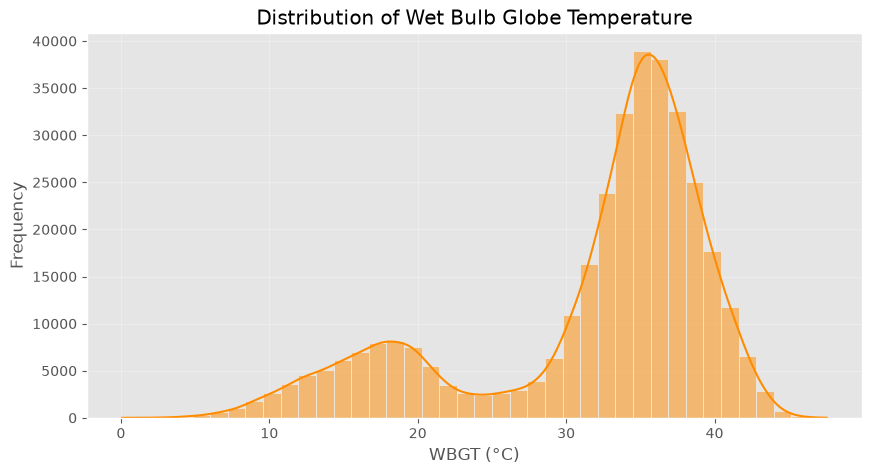

In [15]:
# ============================================================
# 8. WBGT Distribution
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["WBGT"],
    bins=40,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Wet Bulb Globe Temperature")

plt.xlabel("WBGT (°C)")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

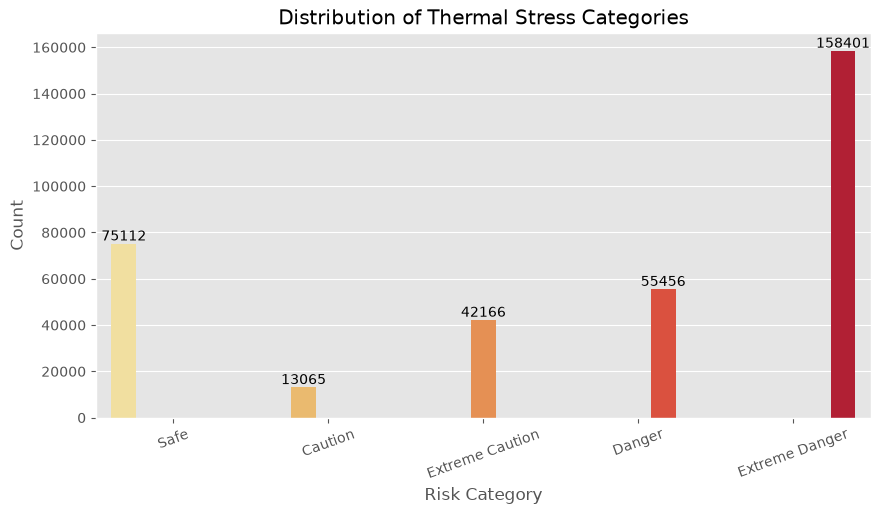

In [16]:
# ============================================================
# 9. Thermal Stress Category Distribution
# ============================================================

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="RiskCategory",
    order=df["RiskCategory"].cat.categories,
    hue="RiskCategory",
    palette="YlOrRd",
    legend=False
)

plt.title("Distribution of Thermal Stress Categories")

plt.xlabel("Risk Category")

plt.ylabel("Count")

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

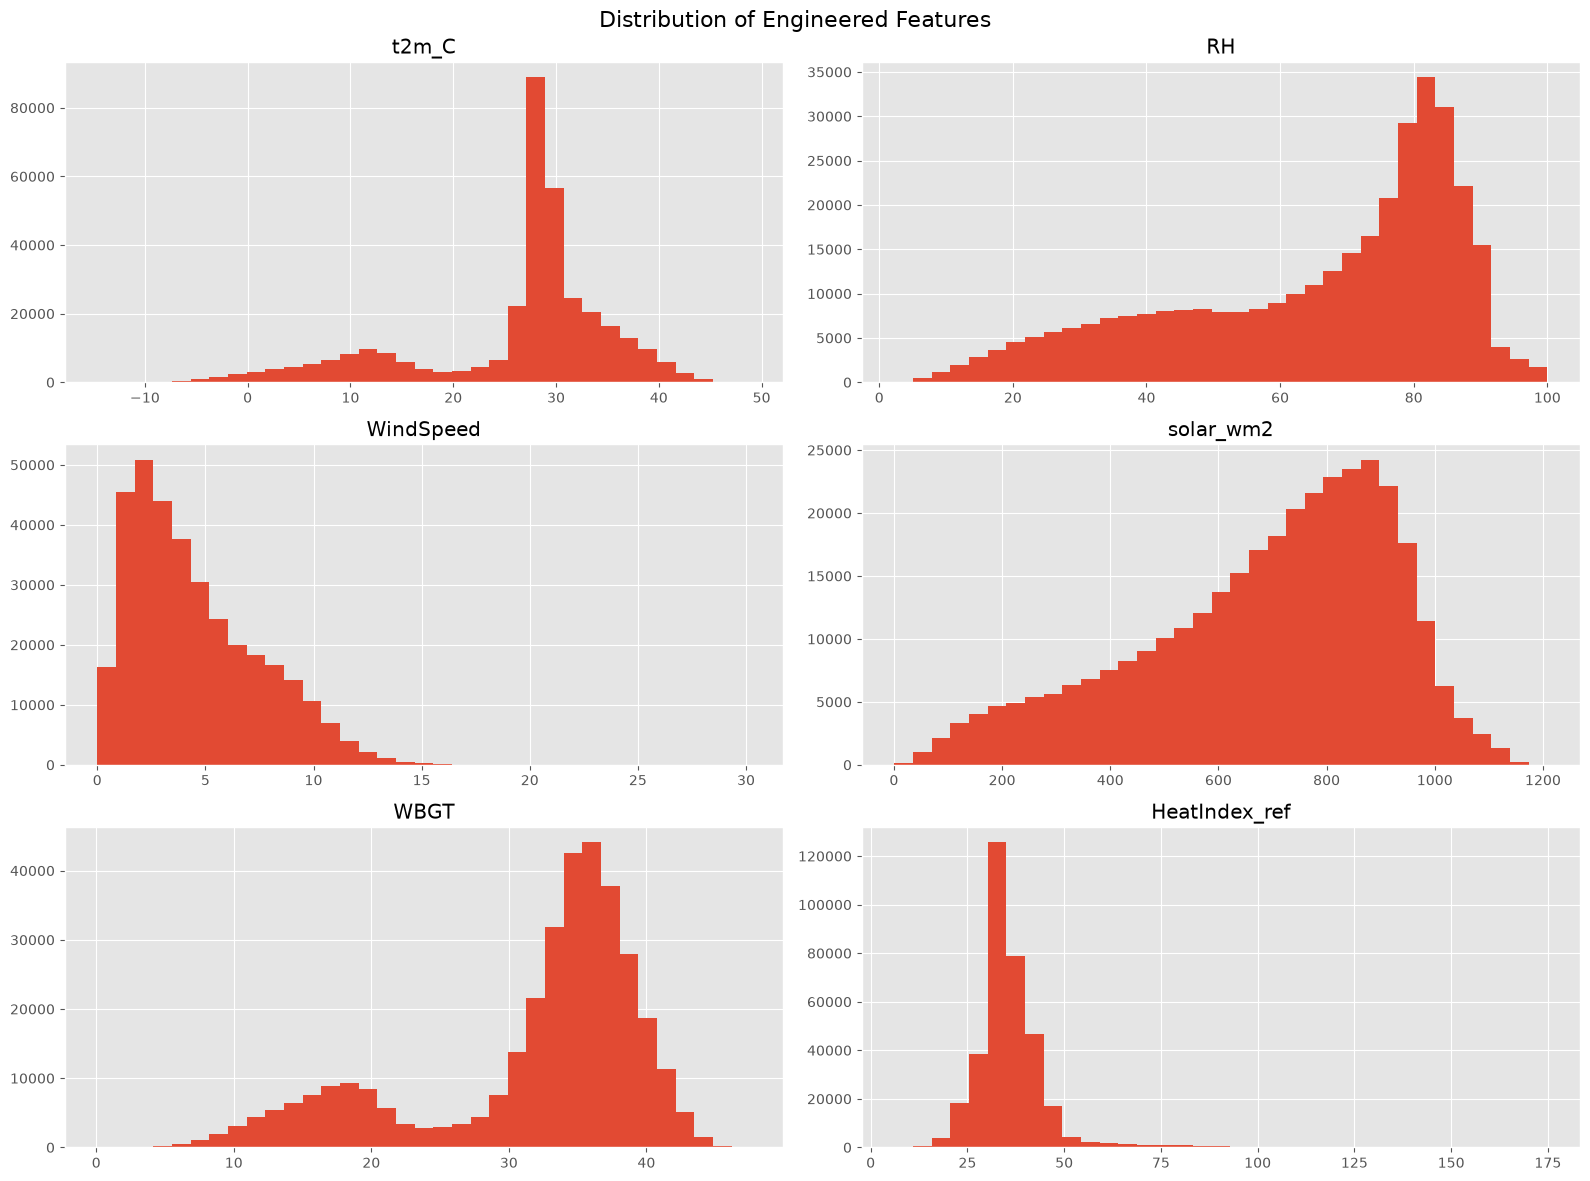

In [17]:
# ============================================================
# 10. Distribution of Engineered Features
# ============================================================

features = [
    "t2m_C",
    "RH",
    "WindSpeed",
    "solar_wm2",
    "WBGT",
    "HeatIndex_ref"
]

df[features].hist(
    figsize=(16,12),
    bins=35
)

plt.suptitle("Distribution of Engineered Features",fontsize=16)

plt.tight_layout()

plt.show()

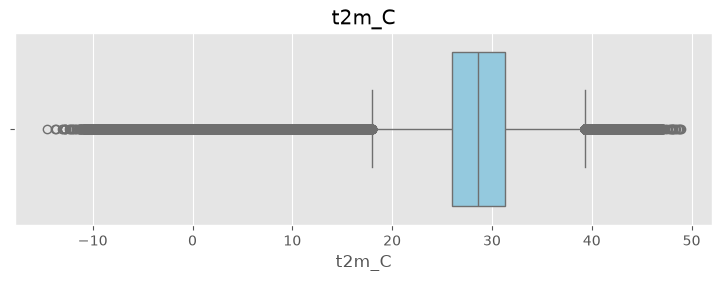

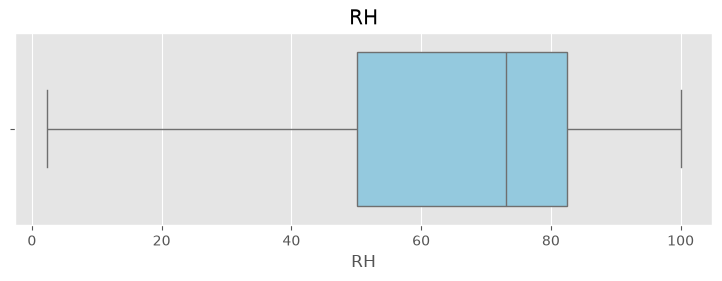

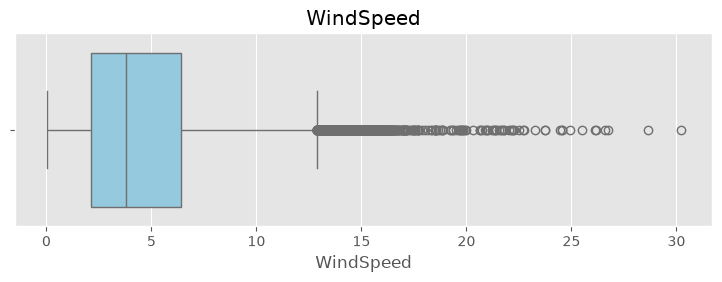

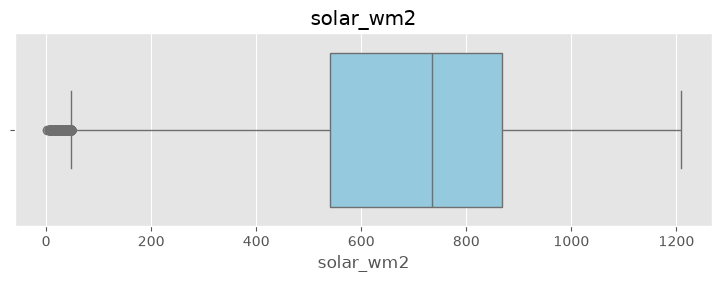

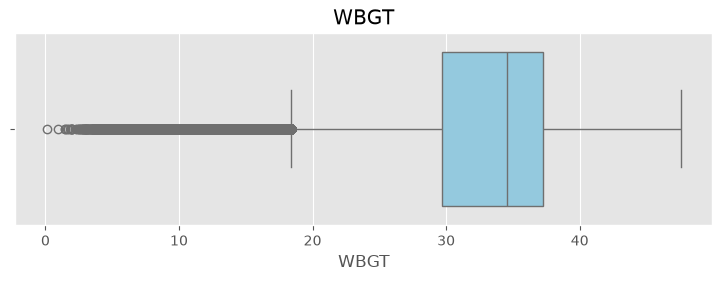

In [18]:
# ============================================================
# 11. Outlier Detection
# ============================================================

features = [
    "t2m_C",
    "RH",
    "WindSpeed",
    "solar_wm2",
    "WBGT"
]

for feature in features:

    plt.figure(figsize=(9,2.5))

    sns.boxplot(
        x=df[feature],
        color="skyblue"
    )

    plt.title(feature)

    plt.show()

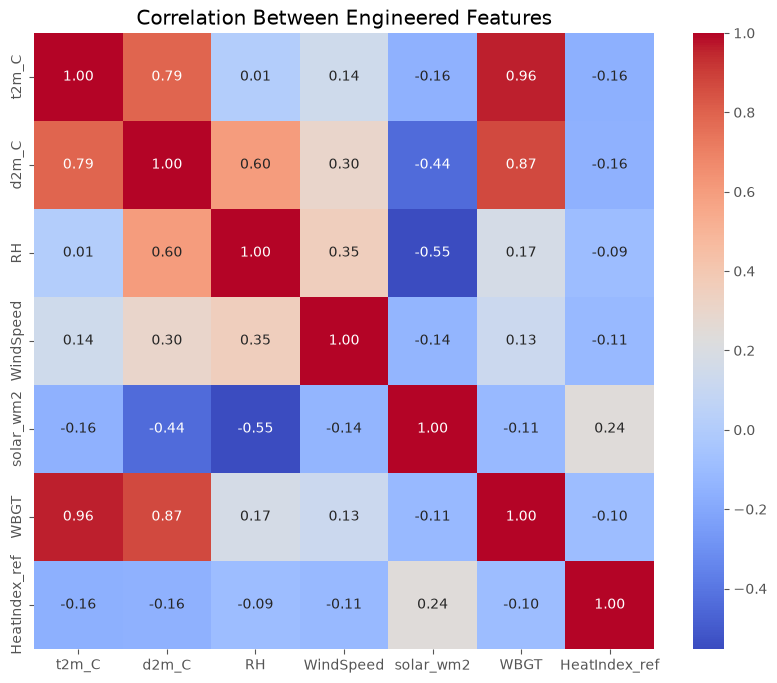

In [19]:
# ============================================================
# 12. Correlation Heatmap
# ============================================================

corr = df[
[
"t2m_C",
"d2m_C",
"RH",
"WindSpeed",
"solar_wm2",
"WBGT",
"HeatIndex_ref"
]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Engineered Features")

plt.show()

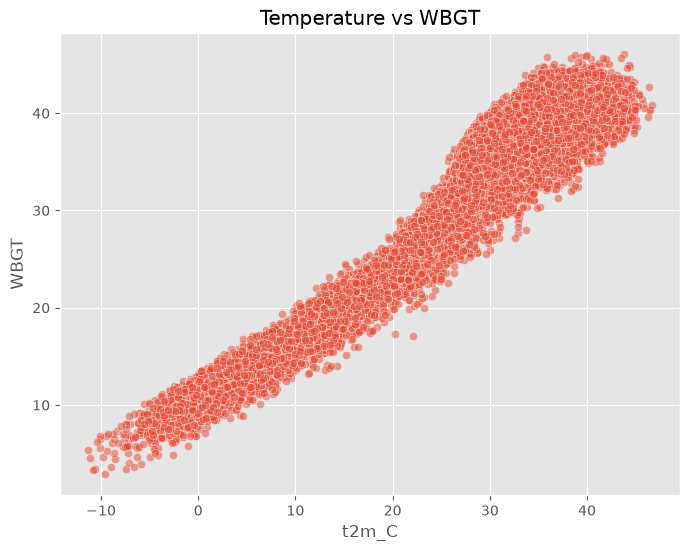

In [20]:
# ============================================================
# 13. Temperature vs WBGT
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(30000),
    x="t2m_C",
    y="WBGT",
    alpha=0.5
)

plt.title("Temperature vs WBGT")

plt.show()

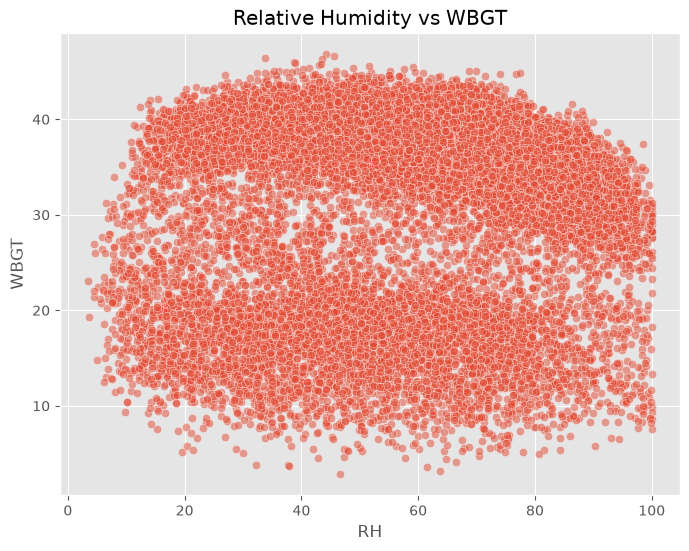

In [21]:
# ============================================================
# 14. Relative Humidity vs WBGT
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(30000),
    x="RH",
    y="WBGT",
    alpha=0.5
)

plt.title("Relative Humidity vs WBGT")

plt.show()

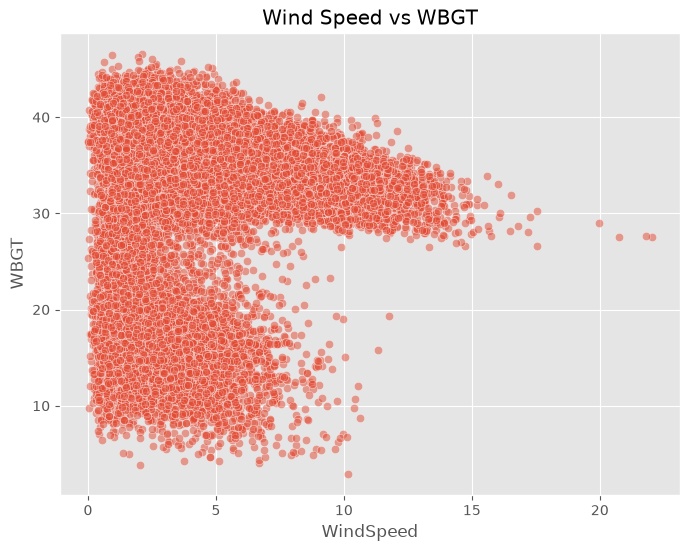

In [22]:
# ============================================================
# 15. Wind Speed vs WBGT
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df.sample(30000),
    x="WindSpeed",
    y="WBGT",
    alpha=0.5
)

plt.title("Wind Speed vs WBGT")

plt.show()

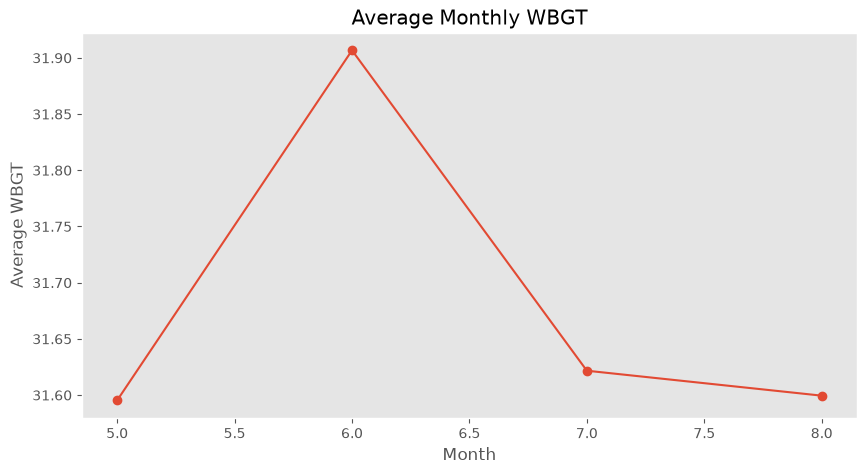

In [23]:
# ============================================================
# 16. Monthly WBGT Trend
# ============================================================

df["valid_time"] = pd.to_datetime(df["valid_time"])

df["Month"] = df["valid_time"].dt.month

monthly = df.groupby("Month")["WBGT"].mean()

plt.figure(figsize=(10,5))

monthly.plot(marker="o")

plt.ylabel("Average WBGT")

plt.title("Average Monthly WBGT")

plt.grid()

plt.show()

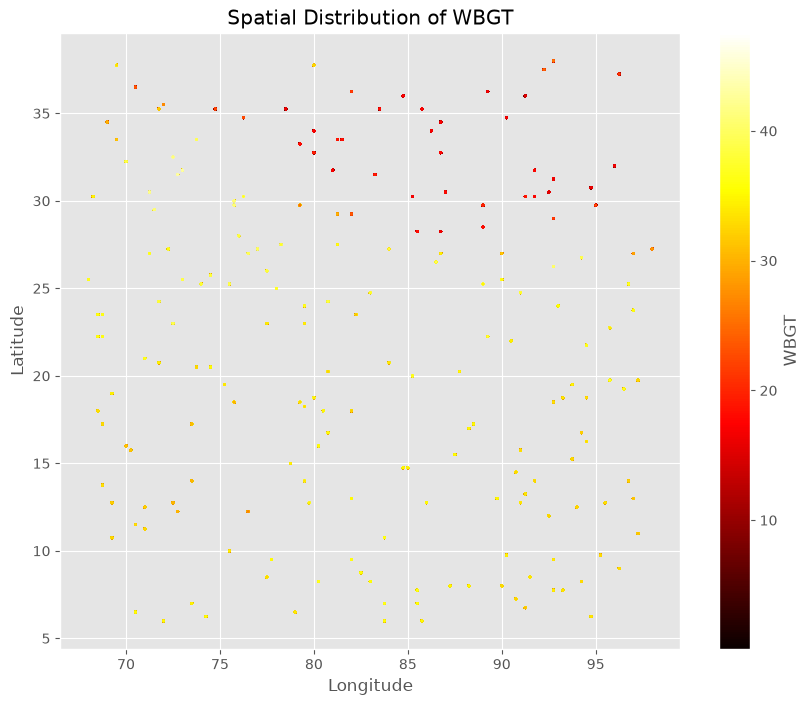

In [24]:
# ============================================================
# 17. Geographic Distribution
# ============================================================

plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["WBGT"],
    cmap="hot",
    s=2
)

plt.colorbar(label="WBGT")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title("Spatial Distribution of WBGT")

plt.show()

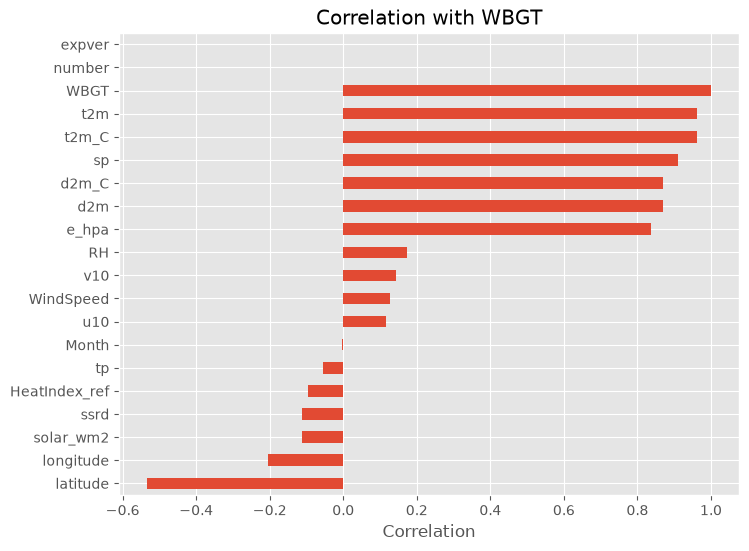

In [25]:
corr = df.corr(numeric_only=True)

target_corr = corr["WBGT"].sort_values()

plt.figure(figsize=(8,6))
target_corr.plot(kind="barh")
plt.title("Correlation with WBGT")
plt.xlabel("Correlation")
plt.grid(True)
plt.show()

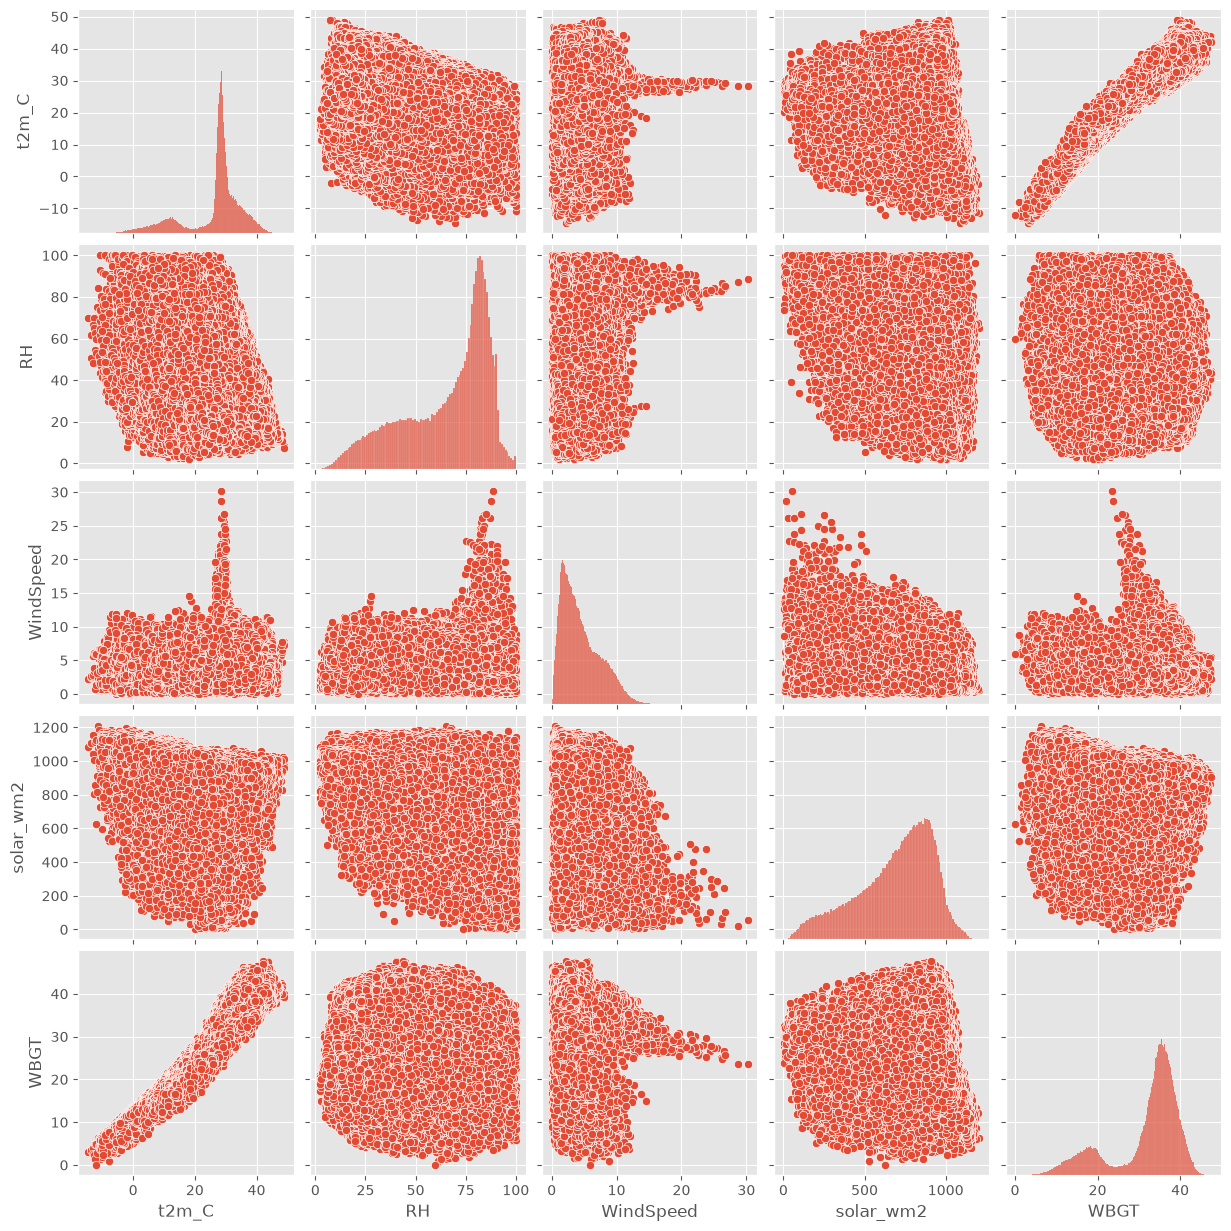

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    "t2m_C",
    "RH",
    "WindSpeed",
    "solar_wm2",
    "WBGT"
]

sns.pairplot(df[cols])
plt.show()


In [30]:
# ============================================================
# 19. Imports & Config
# ============================================================
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

MODEL_DIR = r"E:/sih/models"
os.makedirs(MODEL_DIR, exist_ok=True)

HORIZONS = [3, 4, 5]
TARGET_COLS = [f"WBGT_target_t{h}" for h in HORIZONS]

# Columns that must never be used as features:
# - identifiers / raw date (lat & lon are kept — they carry real spatial signal)
# - day_of_year (redundant with doy_sin/doy_cos, and non-cyclical)
# - the three horizon targets themselves
NON_FEATURE_COLS = ["date", "day_of_year"] + TARGET_COLS

FEATURE_COLS = [c for c in model_df.columns if c not in NON_FEATURE_COLS]

print(f"Using {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)


Using 23 features:
['latitude', 'longitude', 't2m_C', 'RH', 'WindSpeed', 'solar_wm2', 'WBGT', 'WBGT_max', 'WBGT_lag1', 't2m_lag1', 'RH_lag1', 'WBGT_lag2', 't2m_lag2', 'RH_lag2', 'WBGT_lag3', 't2m_lag3', 'RH_lag3', 'WBGT_roll3_mean', 'WBGT_roll7_mean', 'WBGT_roll7_max', 'doy_sin', 'doy_cos', 'WBGT_anomaly']


In [31]:

TEST_FRACTION = 0.15

unique_dates = np.sort(model_df["date"].unique())
split_idx = int(len(unique_dates) * (1 - TEST_FRACTION))
split_date = unique_dates[split_idx]

train_df = model_df[model_df["date"] < split_date].reset_index(drop=True)
test_df  = model_df[model_df["date"] >= split_date].reset_index(drop=True)

print(f"Split date: {pd.Timestamp(split_date).date()}")
print(f"Train: {train_df.shape[0]} rows  ({train_df['date'].min().date()} to {train_df['date'].max().date()})")
print(f"Test : {test_df.shape[0]} rows  ({test_df['date'].min().date()} to {test_df['date'].max().date()})")

# A further chronological slice of TRAIN acts as the validation set
# for early stopping (still no shuffling, still no leakage from test).
val_dates = np.sort(train_df["date"].unique())
val_split_idx = int(len(val_dates) * 0.85)
val_split_date = val_dates[val_split_idx]

fit_df = train_df[train_df["date"] < val_split_date]
val_df = train_df[train_df["date"] >= val_split_date]

print(f"\nFit  : {fit_df.shape[0]} rows")
print(f"Val  : {val_df.shape[0]} rows")


Split date: 2025-08-26
Train: 71200 rows  (2023-05-08 to 2025-08-25)
Test : 12600 rows  (2025-08-26 to 2026-06-26)

Fit  : 60400 rows
Val  : 10800 rows


In [32]:
# ============================================================
# 21. Train One XGBoost Model Per Horizon
# ============================================================
XGB_PARAMS = dict(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric="mae",
)

models = {}
histories = {}

for h in HORIZONS:
    target = f"WBGT_target_t{h}"
    print(f"\n{'='*60}\nTraining model for t+{h} day(s) ahead\n{'='*60}")

    X_fit, y_fit = fit_df[FEATURE_COLS], fit_df[target]
    X_val, y_val = val_df[FEATURE_COLS], val_df[target]

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_fit, y_fit,
        eval_set=[(X_fit, y_fit), (X_val, y_val)],
        verbose=False,
    )

    print(f"Best iteration: {model.best_iteration}  "
          f"(best val MAE: {model.best_score:.3f})")

    models[h] = model
    histories[h] = model.evals_result()



Training model for t+3 day(s) ahead
Best iteration: 131  (best val MAE: 1.716)

Training model for t+4 day(s) ahead
Best iteration: 136  (best val MAE: 1.780)

Training model for t+5 day(s) ahead
Best iteration: 285  (best val MAE: 1.793)


In [33]:
# ============================================================
# 22. Evaluate on Held-Out Test Set
# ============================================================
results = []

for h in HORIZONS:
    target = f"WBGT_target_t{h}"
    X_test, y_test = test_df[FEATURE_COLS], test_df[target]

    y_pred = models[h].predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Naive baseline for comparison: "tomorrow's WBGT = today's WBGT"
    baseline_pred = test_df["WBGT"]
    baseline_mae = mean_absolute_error(y_test, baseline_pred)

    results.append({
        "horizon_days": h,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3),
        "baseline_MAE (persistence)": round(baseline_mae, 3),
        "skill_vs_baseline_%": round(100 * (1 - mae / baseline_mae), 1),
    })

results_df = pd.DataFrame(results)
display(results_df)


,horizon_days,MAE,RMSE,R2,baseline_MAE (persistence),skill_vs_baseline_%
0,3,1.508,1.945,0.956,1.863,19.1
1,4,1.554,2.003,0.953,1.993,22.0
2,5,1.560,2.007,0.953,2.081,25.1


In [34]:
import numpy as np

for h in HORIZONS:
    target = f"WBGT_target_t{h}"

    X_test = test_df[FEATURE_COLS]
    y_test = test_df[target]
    y_pred = models[h].predict(X_test)

    acc1 = np.mean(np.abs(y_test - y_pred) <= 1.0) * 100
    acc2 = np.mean(np.abs(y_test - y_pred) <= 2.0) * 100
    acc3 = np.mean(np.abs(y_test - y_pred) <= 3.0) * 100

    print(f"\nHorizon {h} Days")
    print(f"Accuracy within ±1°C : {acc1:.2f}%")
    print(f"Accuracy within ±2°C : {acc2:.2f}%")
    print(f"Accuracy within ±3°C : {acc3:.2f}%")


Horizon 3 Days
Accuracy within ±1°C : 42.13%
Accuracy within ±2°C : 71.67%
Accuracy within ±3°C : 88.96%

Horizon 4 Days
Accuracy within ±1°C : 40.90%
Accuracy within ±2°C : 70.47%
Accuracy within ±3°C : 87.78%

Horizon 5 Days
Accuracy within ±1°C : 40.68%
Accuracy within ±2°C : 69.85%
Accuracy within ±3°C : 87.24%


In [ ]:
# ============================================================
# 18. Save Processed Dataset
# ============================================================

df.to_csv(
    r"E:\sih\processed_dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")